# Exercises 3 – Car ownership

In [2]:
import pandas as pd


>Load data

In [3]:
df_bilejerskab = pd.read_excel("bilejerskab2026.xlsx")

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [4]:
df_bilejerskab.head()

,ID,HHLicenses,Gender,Children,Year,AgeGroup,LMA,Car,HHIncome,PerIncome
0,1,1,2,0,2008,7,1,1,488,5.0
1,2,2,1,0,2008,6,1,1,753,6.0
2,3,1,1,0,2008,7,1,1,623,4.0
3,4,2,1,2,2008,6,1,2,634,4.0
4,5,2,1,0,2008,7,1,2,1039,8.0


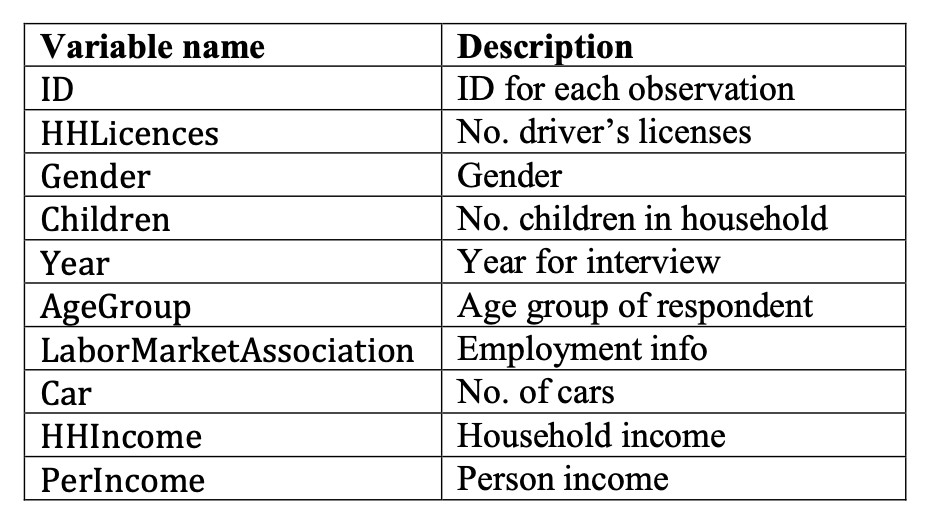

<br>

>a) Find the market shares for 0, 1 and 2 cars in the data. Discuss whether the market shares
change between 2008 and 2009?

Tabel 1: table_marketshare_2008_2009


,Car,Count,MarketSharePct
0,0,618,7.87
1,1,5082,64.71
2,2,2153,27.42


Tabel 2: table_marketshare_2008


,Car,Count,MarketSharePct
0,0,443,8.76
1,1,3476,68.71
2,2,1140,22.53


Tabel 3: table_marketshare_2009


,Car,Count,MarketSharePct
0,0,175,6.26
1,1,1606,57.48
2,2,1013,36.26


Ændring i market share (2009 - 2008), procentpoint:


,Car,MarketSharePct_2009,MarketSharePct_2008,ChangePctPoint
0,0,6.26,8.76,-2.50
1,1,57.48,68.71,-11.23
2,2,36.26,22.53,13.73


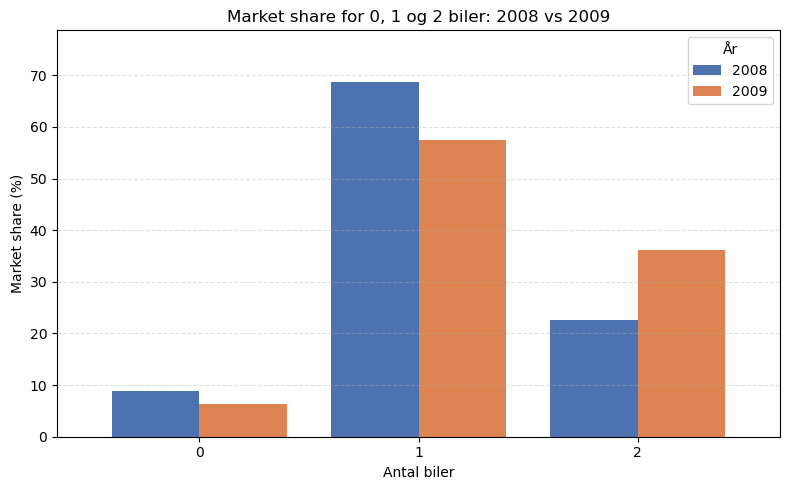

In [5]:
# a) Market shares for 0, 1 and 2 cars
import matplotlib.pyplot as plt

car_levels = [0, 1, 2]

def build_marketshare_table(df):
    counts = df['Car'].value_counts().reindex(car_levels, fill_value=0).sort_index()
    shares = (counts / counts.sum() * 100).round(2)
    return pd.DataFrame({
        'Car': counts.index,
        'Count': counts.values,
        'MarketSharePct': shares.values
    })

# 1) Samlet for begge år (2008 + 2009)
table_marketshare_2008_2009 = build_marketshare_table(
    df_bilejerskab[df_bilejerskab['Year'].isin([2008, 2009])]
    .loc[lambda d: d['Car'].isin(car_levels)]
)

# 2) Kun 2008
table_marketshare_2008 = build_marketshare_table(
    df_bilejerskab[df_bilejerskab['Year'] == 2008]
    .loc[lambda d: d['Car'].isin(car_levels)]
)

# 3) Kun 2009
table_marketshare_2009 = build_marketshare_table(
    df_bilejerskab[df_bilejerskab['Year'] == 2009]
    .loc[lambda d: d['Car'].isin(car_levels)]
)

print('Tabel 1: table_marketshare_2008_2009')
display(table_marketshare_2008_2009)

print('Tabel 2: table_marketshare_2008')
display(table_marketshare_2008)

print('Tabel 3: table_marketshare_2009')
display(table_marketshare_2009)

# Kort sammenligning 2008 vs 2009
comparison_08_09 = (
    table_marketshare_2009[['Car', 'MarketSharePct']]
    .merge(
        table_marketshare_2008[['Car', 'MarketSharePct']],
        on='Car',
        suffixes=('_2009', '_2008')
    )
    .assign(ChangePctPoint=lambda d: (d['MarketSharePct_2009'] - d['MarketSharePct_2008']).round(2))
)

print('Ændring i market share (2009 - 2008), procentpoint:')
display(comparison_08_09)

# Søjlediagram: 2008 og 2009 side om side for Car = 0, 1, 2
plot_df = (
    table_marketshare_2008[['Car', 'MarketSharePct']]
    .rename(columns={'MarketSharePct': '2008'})
    .merge(
        table_marketshare_2009[['Car', 'MarketSharePct']].rename(columns={'MarketSharePct': '2009'}),
        on='Car'
    )
    .set_index('Car')
)

ax = plot_df.plot(kind='bar', figsize=(8, 5), width=0.8, color=['#4C72B0', '#DD8452'])
ax.set_title('Market share for 0, 1 og 2 biler: 2008 vs 2009')
ax.set_xlabel('Antal biler')
ax.set_ylabel('Market share (%)')
ax.set_xticklabels(['0', '1', '2'], rotation=0)
ax.legend(title='År')
ax.set_ylim(0, max(plot_df.max()) + 10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<br>

>b) Describe how the number of cars relates to number of driver’s licenses, income and number
of kids, e.g. using cross tabulation, group averages or correlations. Comment on the results.

In [6]:
# b) Relation between number of cars and licenses, income, and children

# 1) cars_driver_license: average number of cars for HHLicenses = 1,2,3,4,5
cars_driver_license = (
    df_bilejerskab[df_bilejerskab['HHLicenses'].isin([1, 2, 3, 4, 5])]
    .groupby('HHLicenses', as_index=False)
    .agg(
        AvgCars=('Car', 'mean'),
        N=('Car', 'size')
    )
    .sort_values('HHLicenses')
)
cars_driver_license['AvgCars'] = cars_driver_license['AvgCars'].round(3)

# 2) cars_income: average number of cars by HHIncome intervals (quantile-based bins)
income_bins = pd.qcut(df_bilejerskab['HHIncome'], q=5, duplicates='drop')
cars_income = (
    df_bilejerskab.assign(HHIncomeInterval=income_bins)
    .groupby('HHIncomeInterval', as_index=False, observed=False)
    .agg(
        AvgCars=('Car', 'mean'),
        N=('Car', 'size')
    )
    .sort_values('HHIncomeInterval')
)
cars_income['AvgCars'] = cars_income['AvgCars'].round(3)

# 3) cars_kids: average number of cars for Children = 0,1,2,3,4,5,6
cars_kids = (
    df_bilejerskab[df_bilejerskab['Children'].isin([0, 1, 2, 3, 4, 5, 6])]
    .groupby('Children', as_index=False)
    .agg(
        AvgCars=('Car', 'mean'),
        N=('Car', 'size')
    )
    .sort_values('Children')
)
cars_kids['AvgCars'] = cars_kids['AvgCars'].round(3)

print('cars_driver_license')
display(cars_driver_license)

print('cars_income')
display(cars_income)

print('cars_kids')
display(cars_kids)

cars_driver_license


,HHLicenses,AvgCars,N
0,1,0.819,1167
1,2,1.269,5973
2,3,1.484,490
3,4,1.521,73
4,5,1.250,4


cars_income


,HHIncomeInterval,AvgCars,N
0,"(-0.001, 349.0]",0.848,1577
1,"(349.0, 525.8]",1.116,1564
2,"(525.8, 657.0]",1.262,1592
3,"(657.0, 811.0]",1.318,1567
4,"(811.0, 10558.0]",1.435,1553


cars_kids


,Children,AvgCars,N
0,0,1.121,4629
1,1,1.250,1186
2,2,1.309,1506
3,3,1.396,470
4,4,1.440,50
5,5,1.500,10
6,6,0.500,2


**Kommentar til resultater (b)**
- **Driver's licenses:** Gennemsnitligt antal biler stiger fra ca. 0.82 (1 licens) til ca. 1.52 (4 licenser). Kategorien med 5 licenser har meget få observationer (N=4), så den er usikker.
- **Indkomst:** Der er en tydelig positiv sammenhaeng mellem indkomst og antal biler. AvgCars stiger gradvist fra ca. 0.85 i laveste interval til ca. 1.44 i hoejeste interval.
- **Boern:** AvgCars stiger overordnet med antal boern (fra ca. 1.12 ved 0 boern til ca. 1.50 ved 5 boern). Kategorien med 6 boern har kun N=2 og boer tolkes med stor forsigtighed.

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# 1) Cross tabulations (row percentages) with N
crosstab_license = pd.crosstab(
    df_bilejerskab["HHLicenses"],
    df_bilejerskab["Car"],
    normalize="index"
).round(3)
crosstab_license["N"] = df_bilejerskab.groupby("HHLicenses").size()

crosstab_kids = pd.crosstab(
    df_bilejerskab["Children"],
    df_bilejerskab["Car"],
    normalize="index"
).round(3)
crosstab_kids["N"] = df_bilejerskab.groupby("Children").size()

# Crosstab for income with fixed intervals + N
income_bins = [0, 300, 500, 700, 900, 1200, np.inf]
income_labels = [
    "0-300",
    "301-500",
    "501-700",
    "701-900",
    "901-1200",
    "1200+"
]
income_intervals_for_crosstab = pd.cut(
    df_bilejerskab["HHIncome"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
    )
crosstab_income = pd.crosstab(
    income_intervals_for_crosstab,
    df_bilejerskab["Car"],
    normalize="index"
).round(3)
crosstab_income["N"] = income_intervals_for_crosstab.value_counts().reindex(crosstab_income.index).astype(int)

# 3) Spearman correlations
corr_rows = []
for x in ["HHLicenses", "HHIncome", "Children"]:
    rho, pval = spearmanr(df_bilejerskab["Car"], df_bilejerskab[x], nan_policy="omit")
    corr_rows.append({"Variable": x, "SpearmanRho": round(rho, 3), "PValue": pval})

correlation_table = pd.DataFrame(corr_rows)

print("Cross tab: Car vs HHLicenses (row shares + N)")
display(crosstab_license)

print("Cross tab: Car vs Children (row shares + N)")
display(crosstab_kids)

print("Cross tab: Car vs HHIncome interval (fixed intervals, row shares + N)")
display(crosstab_income)

print("Spearman correlations with Car")
display(correlation_table)

Cross tab: Car vs HHLicenses (row shares + N)


Car,0,1,2,N
HHLicenses,,,,
0,0.952,0.048,0.000,146
1,0.215,0.751,0.034,1167
2,0.038,0.655,0.307,5973
3,0.004,0.508,0.488,490
4,0.014,0.452,0.534,73
5,0.000,0.750,0.250,4


Cross tab: Car vs Children (row shares + N)


Car,0,1,2,N
Children,,,,
0,0.103,0.672,0.225,4629
1,0.060,0.631,0.309,1186
2,0.037,0.617,0.346,1506
3,0.023,0.557,0.419,470
4,0.020,0.520,0.460,50
5,0.000,0.500,0.500,10
6,0.500,0.500,0.000,2


Cross tab: Car vs HHIncome interval (fixed intervals, row shares + N)


Car,0,1,2,N
HHIncome,,,,
0-300,0.248,0.691,0.061,1198
301-500,0.103,0.733,0.165,1579
501-700,0.040,0.664,0.296,2437
701-900,0.024,0.602,0.374,1576
901-1200,0.025,0.525,0.451,728
1200+,0.015,0.445,0.540,335


Spearman correlations with Car


,Variable,SpearmanRho,PValue
0,HHLicenses,0.365,1.978236e-245
1,HHIncome,0.352,1.479155e-227
2,Children,0.166,1.318896e-49


<br>

>c) Estimate a logistic regression, where you model whether a family has a car or not. Include
as many variables as possible to explain behaviour and consider non-linear effects. Comment
on the estimated parameters and argue for your choice of final model.

Dummier for aldersgrupper

In [8]:
# Create dummy columns for AgeGroup
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

agegroup_map = {
    2: '8-14',
    3: '15-18',
    4: '19-24',
    5: '25-29',
    6: '30-54',
    7: '55-64',
    8: '65-74',
    9: '75-84'
}

df_bilejerskab['AgeGroupLabel'] = df_bilejerskab['AgeGroup'].map(agegroup_map)

agegroup_dummies = pd.get_dummies(df_bilejerskab['AgeGroupLabel'], prefix='AgeGroup')
df_bilejerskab = pd.concat([df_bilejerskab, agegroup_dummies], axis=1)

df_bilejerskab[['AgeGroup', 'AgeGroupLabel'] + list(agegroup_dummies.columns)].head()

,AgeGroup,AgeGroupLabel,AgeGroup_15-18,AgeGroup_19-24,AgeGroup_25-29,AgeGroup_30-54,AgeGroup_55-64,AgeGroup_65-74,AgeGroup_75-84,AgeGroup_8-14
0,7,55-64,False,False,False,False,True,False,False,False
1,6,30-54,False,False,False,True,False,False,False,False
2,7,55-64,False,False,False,False,True,False,False,False
3,6,30-54,False,False,False,True,False,False,False,False
4,7,55-64,False,False,False,False,True,False,False,False


Dummies for om de har en bil

In [10]:
# Binary target for logistic regression: 1 if the family has at least one car, otherwise 0
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

df_bilejerskab['HaveCar'] = df_bilejerskab['Car'].isin([1, 2]).astype(int)

df_bilejerskab[['Car', 'HaveCar']].head()

,Car,HaveCar
0,1,1
1,1,1
2,1,1
3,2,1
4,2,1


Dummies for beskæftigelse

In [11]:
# Create dummy columns for LMA using the supplied ID mapping
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

lma_map = {
    1: 'Fuldtidsjob',
    2: 'Deltidsjob',
    3: 'Elev_eller_studerende',
    4: 'Pensioneret',
    5: 'Arbejdssoegende',
    6: 'Uden_for_arbejdsmarkedet'
}

df_bilejerskab['LMA_Label'] = df_bilejerskab['LMA'].map(lma_map)

lma_dummies = pd.get_dummies(df_bilejerskab['LMA_Label'], prefix='LMA')
# Rename columns to remove spaces
lma_dummies.columns = lma_dummies.columns.str.replace(' ', '_').str.replace('ø', 'o').str.replace('æ', 'ae')
df_bilejerskab = pd.concat([df_bilejerskab, lma_dummies], axis=1)

df_bilejerskab[['LMA', 'LMA_Label'] + list(lma_dummies.columns)].head()

,LMA,LMA_Label,LMA_Arbejdssoegende,LMA_Deltidsjob,LMA_Elev_eller_studerende,LMA_Fuldtidsjob,LMA_Pensioneret,LMA_Uden_for_arbejdsmarkedet
0,1,Fuldtidsjob,False,False,False,True,False,False
1,1,Fuldtidsjob,False,False,False,True,False,False
2,1,Fuldtidsjob,False,False,False,True,False,False
3,1,Fuldtidsjob,False,False,False,True,False,False
4,1,Fuldtidsjob,False,False,False,True,False,False


Dummy for køn

In [12]:
# Create binary dummy for Gender: Male (1) = 0, Female (2) = 1
df_bilejerskab['Female'] = (df_bilejerskab['Gender'] == 2).astype(int)

df_bilejerskab[['Gender', 'Female']].head()

,Gender,Female
0,2,1
1,1,0
2,1,0
3,1,0
4,1,0


Dummies for Licenses

Her laves for 0, 1 og 2+. Dette er en vurdering ud fra at kigge på Cross Tables

In [13]:
# Create dummies for HHLicenses with 0 licenses as reference
# 1 license gets its own dummy, and 2+ licenses are grouped together.
def add_hhlicenses_dummies(df, source_col='HHLicenses'):
    df = df.copy()
    df['HHLicenses_1'] = (df[source_col] == 1).astype(int)
    df['HHLicenses_2plus'] = df[source_col].isin([2, 3, 4, 5]).astype(int)
    return df

# Quick check on the transformed columns
df_bilejerskab = add_hhlicenses_dummies(df_bilejerskab)
df_bilejerskab[['HHLicenses', 'HHLicenses_1', 'HHLicenses_2plus']].head()

,HHLicenses,HHLicenses_1,HHLicenses_2plus
0,1,1,0
1,2,0,1
2,1,1,0
3,2,0,1
4,2,0,1


Første modelestimation

Der laves ikke dummy for børn da 90% af husstande uden barn allerede har en bil. Så der vil være lille forskel

In [14]:
# Full logistic regression model - restart with fresh data
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Reload data fresh and rebuild all dummies cleanly
df_model = pd.read_excel('bilejerskab2026.xlsx')

# Create binary target
df_model['HaveCar'] = df_model['Car'].isin([1, 2]).astype(int)

# Create HHLicenses dummies with 0 licenses as reference
df_model = add_hhlicenses_dummies(df_model)

# Create Female dummy
df_model['Female'] = (df_model['Gender'] == 2).astype(int)

# Create AgeGroup dummies - use values WITHOUT the prefix, then add prefix='AgeG'
agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 
                6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map)
agegroup_dummies = pd.get_dummies(df_model['AgeGroup_Label'], prefix='AgeG')
df_model = pd.concat([df_model, agegroup_dummies], axis=1)

# Create LMA dummies - use values WITHOUT prefix, then add prefix='LMA'
lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 
           4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
lma_dummies = pd.get_dummies(df_model['LMA_Label'], prefix='LMA')
df_model = pd.concat([df_model, lma_dummies], axis=1)

# Drop the temporary label columns - they should not be in the model
df_model = df_model.drop(columns=['AgeGroup_Label', 'LMA_Label'])

# Get list of dummy columns
age_cols = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
lma_cols = sorted([col for col in df_model.columns if col.startswith('LMA_')])

# Remove reference categories
age_cols = [col for col in age_cols if col != 'AgeG_30_54']  # Reference: 30-54 years
lma_cols = [col for col in lma_cols if col != 'LMA_Fuldtid']  # Reference: Full-time job

print(f"AgeGroup dummies (reference AgeG_30_54 excluded): {age_cols}")
print(f"LMA dummies (reference LMA_Fuldtid excluded): {lma_cols}")
print("HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)")

# Build formula with HHIncome, PerIncome, and all dummies (excluding reference categories)
formula = 'HaveCar ~ HHIncome + PerIncome + Female + HHLicenses_1 + HHLicenses_2plus + Children + ' + \
          ' + '.join(age_cols) + ' + ' + ' + '.join(lma_cols)

print(f"\nFormula:\n{formula}\n")

# Fit logit model
logit_model = smf.logit(formula, data=df_model).fit()

# Standard summary view
print(logit_model.summary())

AgeGroup dummies (reference AgeG_30_54 excluded): ['AgeG_15_18', 'AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84', 'AgeG_8_14']
LMA dummies (reference LMA_Fuldtid excluded): ['LMA_Arbsog', 'LMA_Deltid', 'LMA_Elev_Stud', 'LMA_Pens', 'LMA_Uden_Arb']
HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)

Formula:
HaveCar ~ HHIncome + PerIncome + Female + HHLicenses_1 + HHLicenses_2plus + Children + AgeG_15_18 + AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + AgeG_8_14 + LMA_Arbsog + LMA_Deltid + LMA_Elev_Stud + LMA_Pens + LMA_Uden_Arb

Optimization terminated successfully.
         Current function value: 0.164473
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                HaveCar   No. Observations:                 7821
Model:                          Logit   Df Residuals:                     7802
Method:                           MLE   Df Model:    

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Undersøgelse af non-linear effects